<a href="https://colab.research.google.com/github/Melvin0163/Codsoft-Task1/blob/main/SOP_review1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import ee
ee.Authenticate()
ee.Initialize(project='crested-bonfire-483116-v5')

In [60]:
print(ee.Number(1).getInfo())

1


In [61]:
import ee
import geemap
# Approximate India bounding box
india_bbox = ee.Geometry.Rectangle([
    68.0, 6.0,   # min lon, min lat
    97.0, 36.0   # max lon, max lat
])
era5 = ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")

# Pick a known heatwave date (example)
image = (
    era5
    .filterDate("2020-01-01", "2024-12-31")
    .select("temperature_2m")
    .first()
)
Map = geemap.Map(center=[22, 80], zoom=4)

vis_params = {
    'min': 290,
    'max': 320,
    'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']
}

Map.addLayer(image.clip(india_bbox), vis_params, "ERA5 Temperature (K)")
Map


Map(center=[22, 80], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tran…

In [62]:
image_c = image.subtract(273.15)

vis_params_c = {
    'min': -20,
    'max': 45,
    'palette': ['blue', 'cyan', 'yellow', 'orange', 'red']
}

task = ee.batch.Export.image.toDrive(
    image=image_c.visualize(**vis_params_c),
    description="ERA5_Global_Temp_4K",
    folder="EarthEngineExports",
    fileNamePrefix="ERA5_Global_Temp_4K",
    region=ee.Geometry.Rectangle([-180, -90, 180, 90]),
    crs="EPSG:4326",
    dimensions="3840x2160",
    fileFormat="GeoTIFF",   # <-- MUST be GeoTIFF
    maxPixels=1e13
)

task.start()

In [63]:
# Check what bands actually exist in ERA5 DAILY
first_image = ee.Image(ee.ImageCollection("ECMWF/ERA5/DAILY").first())
print(first_image.bandNames().getInfo())

['mean_2m_air_temperature', 'minimum_2m_air_temperature', 'maximum_2m_air_temperature', 'dewpoint_2m_temperature', 'total_precipitation', 'surface_pressure', 'mean_sea_level_pressure', 'u_component_of_wind_10m', 'v_component_of_wind_10m']


In [64]:
print(ee.Number(1).getInfo())
# → 1

1


In [65]:
first_image = ee.Image(
    ee.ImageCollection("ECMWF/ERA5/DAILY").first()
)
print(first_image.bandNames().getInfo())

['mean_2m_air_temperature', 'minimum_2m_air_temperature', 'maximum_2m_air_temperature', 'dewpoint_2m_temperature', 'total_precipitation', 'surface_pressure', 'mean_sea_level_pressure', 'u_component_of_wind_10m', 'v_component_of_wind_10m']


In [66]:
era5 = (
    ee.ImageCollection("ECMWF/ERA5_LAND/DAILY_AGGR")
    .filterDate("2010-01-01", "2025-12-31")
    .select([
        "temperature_2m",
        "surface_pressure",
        "total_precipitation_sum"
    ])
)

print("Number of images:", era5.size().getInfo())


Number of images: 5843


In [67]:
point = ee.Geometry.Point([80.23, 13.08])

In [68]:
import pandas as pd

# Get time series for a point
data = era5.getRegion(point, 1000).getInfo()

# Convert to DataFrame
df = pd.DataFrame(data)

# The first row contains headers, remove it and rename columns
headers = df.iloc[0]
df = pd.DataFrame(df.values[1:], columns=headers)

# Convert relevant columns to numeric
df['temperature_2m'] = pd.to_numeric(df['temperature_2m'], errors='coerce')
df['surface_pressure'] = pd.to_numeric(df['surface_pressure'], errors='coerce')
df['total_precipitation_sum'] = pd.to_numeric(df['total_precipitation_sum'], errors='coerce')

# The 'time' column contains milliseconds since epoch, convert it to datetime
df['time'] = pd.to_datetime(df['time'], unit='ms')

# Set 'time' as index for time series operations
df = df.set_index('time')

df.head()

,id,longitude,latitude,temperature_2m,surface_pressure,total_precipitation_sum
time,,,,,,
2010-01-01,20100101,80.23303,13.083962,297.621471,101107.935221,1.659989e-05
2010-01-02,20100102,80.23303,13.083962,297.483919,101250.684570,1.224685e-03
2010-01-03,20100103,80.23303,13.083962,296.871827,101206.095540,3.372908e-04
2010-01-04,20100104,80.23303,13.083962,295.963725,101003.161621,0.000000e+00
2010-01-05,20100105,80.23303,13.083962,296.195395,100900.010091,4.351138e-07


In [69]:
df.shape

(5843, 6)

In [70]:
df.head(10)

,id,longitude,latitude,temperature_2m,surface_pressure,total_precipitation_sum
time,,,,,,
2010-01-01,20100101,80.23303,13.083962,297.621471,101107.935221,1.659989e-05
2010-01-02,20100102,80.23303,13.083962,297.483919,101250.684570,1.224685e-03
2010-01-03,20100103,80.23303,13.083962,296.871827,101206.095540,3.372908e-04
2010-01-04,20100104,80.23303,13.083962,295.963725,101003.161621,0.000000e+00
2010-01-05,20100105,80.23303,13.083962,296.195395,100900.010091,4.351138e-07
2010-01-06,20100106,80.23303,13.083962,297.436220,100953.074544,7.456541e-05
2010-01-07,20100107,80.23303,13.083962,297.848518,101046.387858,1.799348e-03
2010-01-08,20100108,80.23303,13.083962,297.178782,101027.140299,7.304966e-03
2010-01-09,20100109,80.23303,13.083962,297.964490,101005.484375,1.810119e-03


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5843 entries, 2010-01-01 to 2025-12-30
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       5843 non-null   object 
 1   longitude                5843 non-null   object 
 2   latitude                 5843 non-null   object 
 3   temperature_2m           5843 non-null   float64
 4   surface_pressure         5843 non-null   float64
 5   total_precipitation_sum  5843 non-null   float64
dtypes: float64(3), object(3)
memory usage: 319.5+ KB


In [72]:
df['temperature_C'] = df['temperature_2m'] - 273.15
df[['temperature_C']]

,temperature_C
time,
2010-01-01,24.471471
2010-01-02,24.333919
2010-01-03,23.721827
2010-01-04,22.813725
2010-01-05,23.045395
...,...
2025-12-26,23.660551
2025-12-27,23.304240
2025-12-28,23.527797


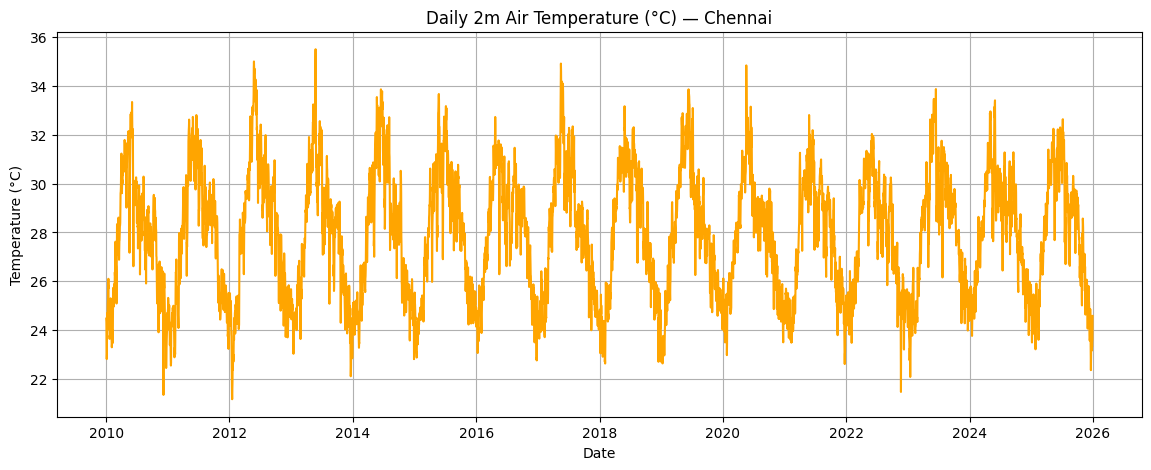

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(df.index, df['temperature_C'], color='orange')
plt.title("Daily 2m Air Temperature (°C) — Chennai")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [74]:
heat_threshold = df['temperature_C'].quantile(0.90)
heat_threshold

np.float64(31.282088470458998)

In [75]:
heat_threshold = df['temperature_C'].quantile(0.90)
df['is_heatwave'] = df['temperature_C'] > heat_threshold
df[['temperature_C','is_heatwave']].head(10)

,temperature_C,is_heatwave
time,,
2010-01-01,24.471471,False
2010-01-02,24.333919,False
2010-01-03,23.721827,False
2010-01-04,22.813725,False
2010-01-05,23.045395,False
2010-01-06,24.286220,False
2010-01-07,24.698518,False
2010-01-08,24.028782,False
2010-01-09,24.814490,False


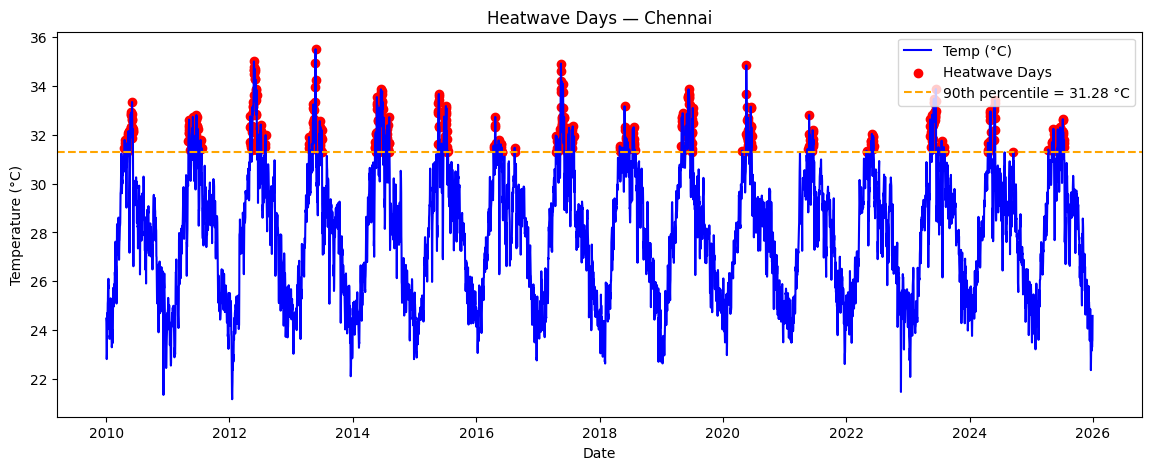

In [76]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['temperature_C'], label="Temp (°C)", color='blue')
plt.scatter(df[df['is_heatwave']].index,
            df[df['is_heatwave']]['temperature_C'],
            color='red', label='Heatwave Days')

plt.axhline(heat_threshold, linestyle='--', color='orange',
            label=f"90th percentile = {heat_threshold:.2f} °C")

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("Heatwave Days — Chennai")
plt.legend()
plt.show()

In [77]:
total_heatwave_days = df['is_heatwave'].sum()
print("Total number of heatwave days:", total_heatwave_days)

first_hw = df.loc[df['is_heatwave'] == True].index.min()
print("First heatwave day:", first_hw.date())

Total number of heatwave days: 585
First heatwave day: 2010-04-19


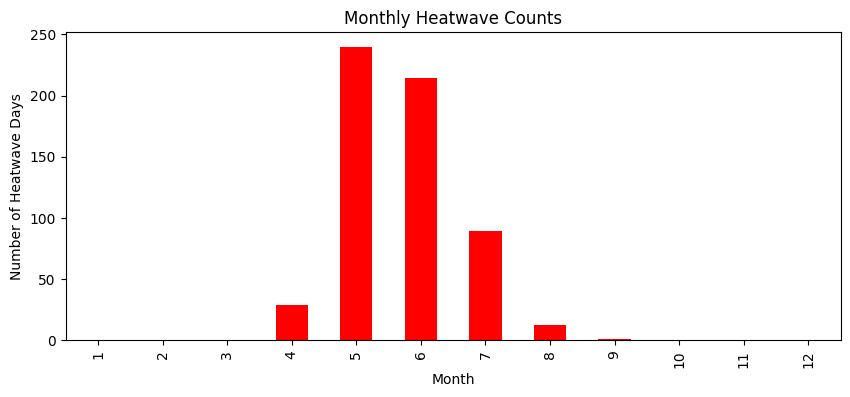

In [78]:
df['month'] = df.index.month
monthly_counts = df.groupby('month')['is_heatwave'].sum()

plt.figure(figsize=(10,4))
monthly_counts.plot(kind='bar', color='red')
plt.title("Monthly Heatwave Counts")
plt.xlabel("Month")
plt.ylabel("Number of Heatwave Days")
plt.show()

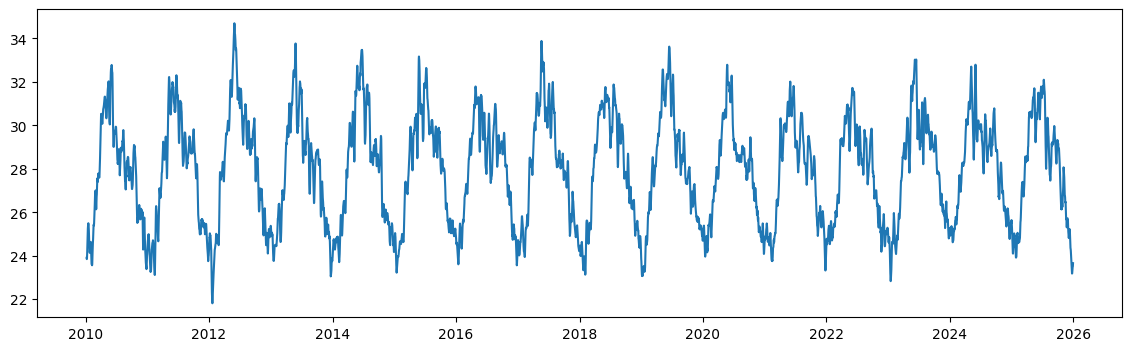

In [79]:
df['temp_roll_7'] = df['temperature_C'].rolling(window=7).mean()

plt.figure(figsize=(14,4))
plt.plot(df.index, df['temp_roll_7'], label="7-day Moving Avg")
plt.show()

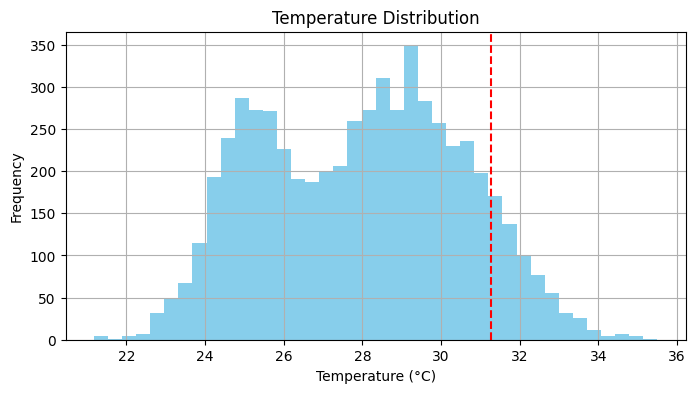

In [80]:
plt.figure(figsize=(8,4))
df['temperature_C'].hist(bins=40, color='skyblue')


plt.axvline(heat_threshold, color='red', label='90th percentile', linestyle='--')
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

In [81]:
df

,id,longitude,latitude,temperature_2m,surface_pressure,total_precipitation_sum,temperature_C,is_heatwave,month,temp_roll_7
time,,,,,,,,,,
2010-01-01,20100101,80.23303,13.083962,297.621471,101107.935221,1.659989e-05,24.471471,False,1,NaN
2010-01-02,20100102,80.23303,13.083962,297.483919,101250.684570,1.224685e-03,24.333919,False,1,NaN
2010-01-03,20100103,80.23303,13.083962,296.871827,101206.095540,3.372908e-04,23.721827,False,1,NaN
2010-01-04,20100104,80.23303,13.083962,295.963725,101003.161621,0.000000e+00,22.813725,False,1,NaN
2010-01-05,20100105,80.23303,13.083962,296.195395,100900.010091,4.351138e-07,23.045395,False,1,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-12-26,20251226,80.23303,13.083962,296.810551,101147.902018,3.749132e-06,23.660551,False,12,23.298562
2025-12-27,20251227,80.23303,13.083962,296.454240,101192.482585,2.131183e-06,23.304240,False,12,23.433257
2025-12-28,20251228,80.23303,13.083962,296.677797,101216.769694,9.658933e-06,23.527797,False,12,23.492584


In [82]:
# Making a clean copy of the original data
df_true = df.copy()

# Columns we will impute
features = [
    'temperature_C',
    'surface_pressure',
    'total_precipitation_sum'
]

df_true[features].isna().sum()

,0
0,
temperature_C,0
surface_pressure,0
total_precipitation_sum,0


In [83]:
import numpy as np

np.random.seed(42)

df_missing_random = df_true.copy()

missing_fraction = 0.20  # 20% missing

mask_random = np.random.rand(len(df_missing_random)) < missing_fraction

df_missing_random.loc[mask_random, 'temperature_C'] = np.nan

In [84]:
df_missing_block = df_true.copy()

block_length = 30  # days
start_idx = 1000   # arbitrary but fixed for reproducibility

mask_block = np.zeros(len(df_missing_block), dtype=bool)
mask_block[start_idx:start_idx + block_length] = True

df_missing_block.loc[mask_block, 'temperature_C'] = np.nan

In [88]:
df_missing_heatwave = df_true.copy()

# Define heatwave season (India pre-monsoon)
hw_season = df_missing_heatwave.index.month.isin([3, 4, 5, 6])

df_missing_heatwave.loc[hw_season, 'temperature_C'] = np.nan

mask_hw = hw_season

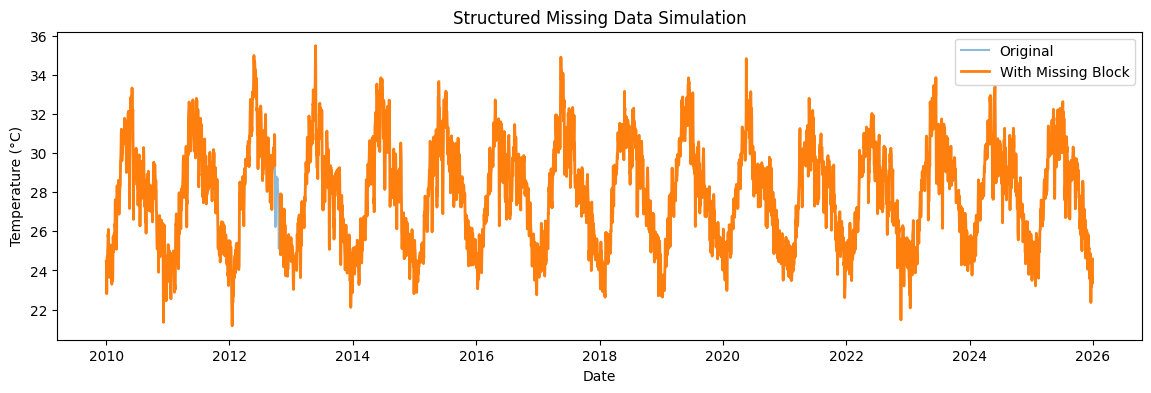

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(df_true.index, df_true['temperature_C'], label='Original', alpha=0.5)
plt.plot(df_missing_block.index, df_missing_block['temperature_C'],
         label='With Missing Block', linewidth=2)

plt.legend()
plt.title("Structured Missing Data Simulation")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

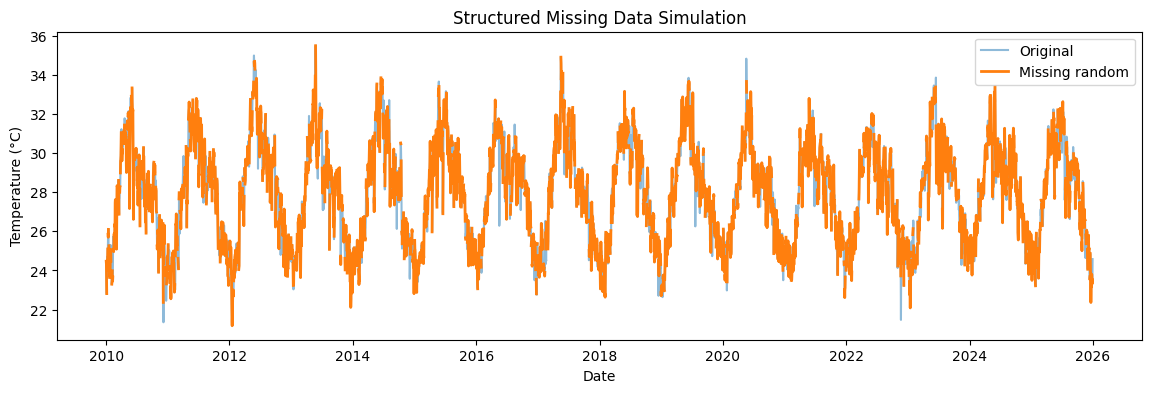

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(df_true.index, df_true['temperature_C'], label='Original', alpha=0.5)
plt.plot(df_missing_random.index, df_missing_random['temperature_C'],
         label='Missing random', linewidth=2)

plt.legend()
plt.title("Structured Missing Data Simulation")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

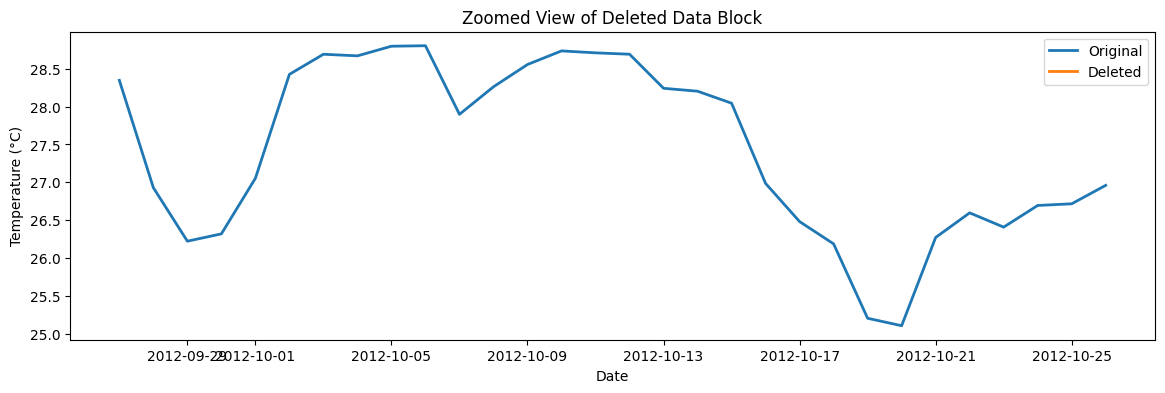

In [96]:
start = start_idx
end = start_idx + block_length

plt.figure(figsize=(14,4))

plt.plot(
    df_true.index[start:end],
    df_true['temperature_C'].iloc[start:end],
    label='Original',
    linewidth=2
)

plt.plot(
    df_missing.index[start:end],
    df_missing['temperature_C'].iloc[start:end],
    label='Deleted',
    linewidth=2
)

plt.legend()
plt.title("Zoomed View of Deleted Data Block")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

In [90]:
SCENARIO = "block"   # choose: "random", "block"

if SCENARIO == "random":
    df_missing = df_missing_random
    mask = mask_random

elif SCENARIO == "block":
    df_missing = df_missing_block
    mask = mask_block

else:
    raise ValueError("Invalid SCENARIO")

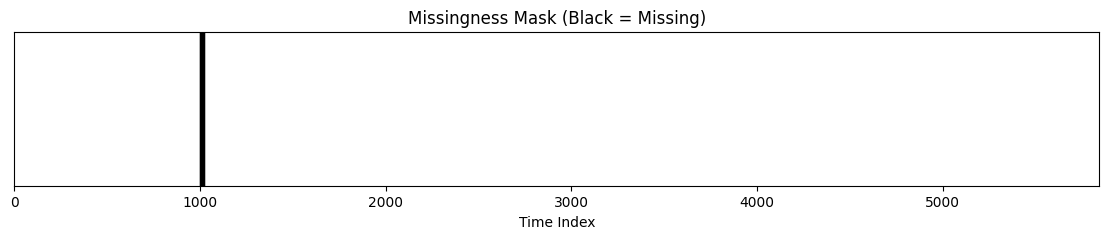

In [91]:
plt.figure(figsize=(14,2))
plt.imshow(1 - mask.reshape(1,-1), cmap="gray", aspect="auto")
plt.yticks([])
plt.xlabel("Time Index")
plt.title("Missingness Mask (Black = Missing)")
plt.show()

In [92]:
print("Missing percentage:", df_missing["temperature_C"].isna().mean())

Missing percentage: 0.005134348793428034


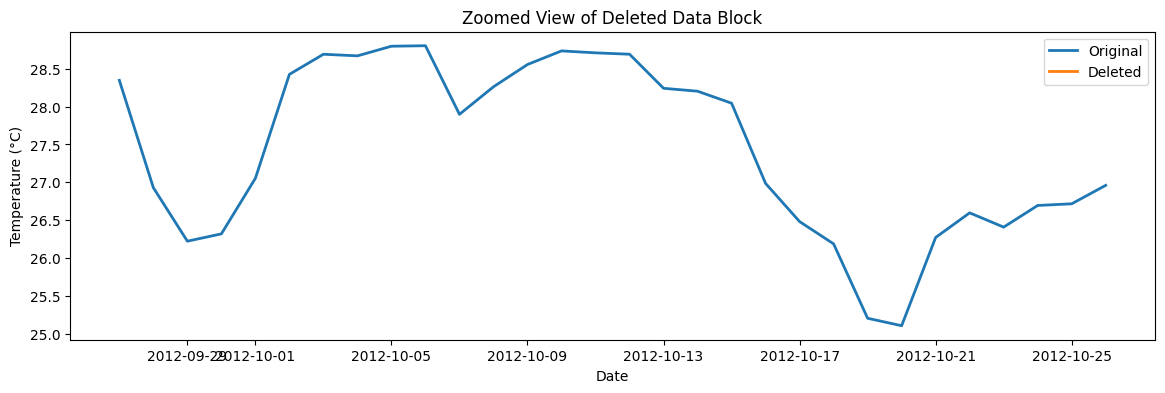

In [104]:
start = start_idx
end = start_idx + block_length

plt.figure(figsize=(14,4))

plt.plot(
    df_true.index[start:end],
    df_true['temperature_C'].iloc[start:end],
    label='Original',
    linewidth=2
)

plt.plot(
    df_missing.index[start:end],
    df_missing['temperature_C'].iloc[start:end],
    label='Deleted',
    linewidth=2
)

plt.legend()
plt.title("Zoomed View of Deleted Data Block")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

In [100]:
print("Missing %:", df_missing.isna().mean())

threshold = np.percentile(df_true["temperature_C"], 95)
print("Heatwave threshold:", threshold)

Missing %: 0
id                         0.000000
longitude                  0.000000
latitude                   0.000000
temperature_2m             0.000000
surface_pressure           0.000000
total_precipitation_sum    0.000000
temperature_C              0.005134
is_heatwave                0.000000
month                      0.000000
temp_roll_7                0.001027
dtype: float64
Heatwave threshold: 32.00979906717939


In [101]:
# #Mean / Linear Interpolation (Classical Baseline)
# df_linear = df_missing.interpolate(method='linear')
# df_ffill = df_missing.fillna(method='ffill')


In [106]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd

series = df_missing["temperature_C"]

# Fit only on non-missing values
model = ARIMA(series.dropna(), order=(5,1,0))
model_fit = model.fit()

# Predict full length. The predict method returns a Series with a RangeIndex
# if the original series has no frequency information.
pred_full_range_indexed = model_fit.predict(start=0, end=len(series)-1)

# Create a new Series with the original DatetimeIndex for proper alignment
pred_full_aligned = pd.Series(pred_full_range_indexed.values, index=series.index)

df_arima = df_missing.copy()

# Replace only missing positions using the aligned prediction
mask_positions = series.isna()
df_arima.loc[mask_positions, "temperature_C"] = pred_full_aligned[mask_positions]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [108]:
#SARIMA (Seasonal ARIMA)
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd # Import pandas for Series

series = df_missing["temperature_C"]

model = SARIMAX(series.dropna(),
                order=(2,1,2),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)

# Predict full series length. The predict method returns a Series with a RangeIndex.
pred_full_range_indexed = results.predict(start=0, end=len(series)-1)

# Create a new Series with the original DatetimeIndex for proper alignment
pred_full_aligned = pd.Series(pred_full_range_indexed.values, index=series.index)

df_sarima = df_missing.copy()

mask_positions = series.isna()
df_sarima.loc[mask_positions, "temperature_C"] = pred_full_aligned[mask_positions]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [109]:
# ==============================
# LSTM-Based Imputation
# ==============================

import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Prepare Data
# ------------------------------

series = df_missing["temperature_C"].values
true_series = df_true["temperature_C"].values

# Normalize
scaler = MinMaxScaler()
true_scaled = scaler.fit_transform(true_series.reshape(-1,1)).flatten()

missing_scaled = scaler.transform(
    df_missing[["temperature_C"]]
).flatten()

mask = np.isnan(missing_scaled).astype(float)
series_filled = np.nan_to_num(missing_scaled, nan=0.0)

# ------------------------------
# Create Sliding Windows
# ------------------------------

window_size = 30

X, Y = [], []

for i in range(len(series_filled) - window_size):
    X.append(series_filled[i:i+window_size])
    Y.append(true_scaled[i:i+window_size])

X = np.array(X)
Y = np.array(Y)

X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1).to(device)
Y_tensor = torch.tensor(Y, dtype=torch.float32).unsqueeze(-1).to(device)

# ------------------------------
# Define LSTM Model
# ------------------------------

class LSTMImputer(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

model = LSTMImputer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# ------------------------------
# Train
# ------------------------------

epochs = 200

for epoch in range(epochs):
    optimizer.zero_grad()
    output = model(X_tensor)
    loss = criterion(output, Y_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# ------------------------------
# Reconstruct Full Series
# ------------------------------

model.eval()

reconstructed = np.zeros(len(series_filled))
counts = np.zeros(len(series_filled))

with torch.no_grad():
    for i in range(len(X)):
        x = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
        out = model(x).cpu().numpy().flatten()

        reconstructed[i:i+window_size] += out
        counts[i:i+window_size] += 1

reconstructed /= counts

# Inverse scale
reconstructed = scaler.inverse_transform(
    reconstructed.reshape(-1,1)
).flatten()

# ------------------------------
# Create df_lstm
# ------------------------------

df_lstm = df_missing.copy()
df_lstm.loc[mask==1, "temperature_C"] = reconstructed[mask==1]

print("df_lstm ready")


Epoch 0, Loss: 0.197763
Epoch 50, Loss: 0.020057
Epoch 100, Loss: 0.006056
Epoch 150, Loss: 0.004629
df_lstm ready


In [110]:
#KNN Imputation
from sklearn.impute import KNNImputer
import pandas as pd

# Select numeric columns only
df_numeric = df_missing.select_dtypes(include=[np.number])

imputer = KNNImputer(n_neighbors=5)

df_knn_array = imputer.fit_transform(df_numeric)

df_knn = pd.DataFrame(df_knn_array,
                      columns=df_numeric.columns,
                      index=df_numeric.index)

# Put back non-numeric columns
for col in df_missing.columns:
    if col not in df_knn.columns:
        df_knn[col] = df_missing[col]

In [111]:
#Main Reconstruction Plot
import matplotlib.pyplot as plt

def plot_all_models(df_true, df_missing, models_dict, mask):

    plt.figure(figsize=(16,6))

    plt.plot(df_true.index, df_true["temperature_C"],
             label="True", color="black", linewidth=2)

    plt.plot(df_missing.index, df_missing["temperature_C"],
             label="Observed (Missing)", color="gray", alpha=0.4)

    for name, df_model in models_dict.items():
        plt.plot(df_model.index, df_model["temperature_C"],
                 label=name, alpha=0.8)

    plt.title("Model Comparison - Imputation")
    plt.legend()
    plt.show()


In [112]:
###GAN
# 1. Setup

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# 2. Prepare Data


# Normalize true data
scaler = MinMaxScaler()
true_vals = df_true[["temperature_C"]].values
scaled_true = scaler.fit_transform(true_vals).flatten()

# Apply scaling to missing data
scaled_missing = scaler.transform(df_missing[["temperature_C"]]).flatten()

mask = np.isnan(scaled_missing).astype(float)
series_filled = np.nan_to_num(scaled_missing, nan=0.0)


# 3. Create Sliding Windows

window_size = 30

X, M, Y = [], [], []

for i in range(len(series_filled) - window_size):
    X.append(series_filled[i:i+window_size])
    M.append(mask[i:i+window_size])
    Y.append(scaled_true[i:i+window_size])

X = np.array(X)
M = np.array(M)
Y = np.array(Y)

class TimeDataset(Dataset):
    def __init__(self, X, M, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.M = torch.tensor(M, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.M[idx], self.Y[idx]

loader = DataLoader(TimeDataset(X, M, Y), batch_size=64, shuffle=True)



# 4. GAN Models
latent_dim = 32
hidden_size = 64

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(2 + latent_dim, hidden_size,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, 1)

    def forward(self, x, mask, z):
        batch_size, seq_len = x.shape
        z_expand = z.unsqueeze(1).repeat(1, seq_len, 1)

        inp = torch.cat([
            x.unsqueeze(-1),
            mask.unsqueeze(-1),
            z_expand
        ], dim=2)

        out, _ = self.lstm(inp)
        out = self.fc(out)
        return out.squeeze(-1)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size,
                            batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2, 1)

    def forward(self, x):
        out, _ = self.lstm(x.unsqueeze(-1))
        out = self.fc(out[:, -1, :])
        return torch.sigmoid(out)

G = Generator().to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=0.0003)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0001)

bce = nn.BCELoss()
mse = nn.MSELoss()


# 5. Training Loop

epochs = 800

for epoch in range(epochs):

    for x_batch, m_batch, y_batch in loader:

        x_batch = x_batch.to(device)
        m_batch = m_batch.to(device)
        y_batch = y_batch.to(device)

        batch_size = x_batch.size(0)

        # -------- Train Discriminator --------
        opt_D.zero_grad()

        z = torch.randn(batch_size, latent_dim).to(device)
        fake = G(x_batch, m_batch, z).detach()

        real_label = torch.ones((batch_size,1)).to(device)
        fake_label = torch.zeros((batch_size,1)).to(device)

        loss_real = bce(D(y_batch), real_label)
        loss_fake = bce(D(fake), fake_label)
        loss_D = loss_real + loss_fake
        loss_D.backward()
        opt_D.step()

        # -------- Train Generator --------
        opt_G.zero_grad()

        z = torch.randn(batch_size, latent_dim).to(device)
        fake = G(x_batch, m_batch, z)

        adv_loss = bce(D(fake), real_label)

        mse_loss = mse(fake * m_batch, y_batch * m_batch)

        smooth_loss = torch.mean((fake[:,1:] - fake[:,:-1])**2)

        var_loss = torch.abs(fake.var(dim=1) - y_batch.var(dim=1)).mean()

        loss_G = (
            20 * mse_loss +
            0.01 * adv_loss +
            0.5 * smooth_loss +
            0.5 * var_loss
        )

        loss_G.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        opt_G.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")


# 6. Reconstruct Full Series

G.eval()

reconstructed = np.zeros(len(series_filled))
counts = np.zeros(len(series_filled))

with torch.no_grad():
    for i in range(len(X)):
        x = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0).to(device)
        m = torch.tensor(M[i], dtype=torch.float32).unsqueeze(0).to(device)
        z = torch.randn(1, latent_dim).to(device)

        out = G(x, m, z).cpu().numpy().flatten()

        reconstructed[i:i+window_size] += out
        counts[i:i+window_size] += 1

reconstructed /= counts

# Inverse scale
reconstructed = scaler.inverse_transform(
    reconstructed.reshape(-1,1)
).flatten()

df_gan = df_missing.copy()
df_gan.loc[mask==1, "temperature_C"] = reconstructed[mask==1]

print("GAN Imputation Completed")


Device: cuda
Epoch 0 | D: 1.3698 | G: 0.0092
Epoch 100 | D: 1.3852 | G: 0.0076
Epoch 200 | D: 1.3856 | G: 0.0083
Epoch 300 | D: 1.3861 | G: 0.0076
Epoch 400 | D: 1.3854 | G: 0.0072
Epoch 500 | D: 1.3818 | G: 0.0074
Epoch 600 | D: 1.3858 | G: 0.0074
Epoch 700 | D: 1.3835 | G: 0.0075
GAN Imputation Completed


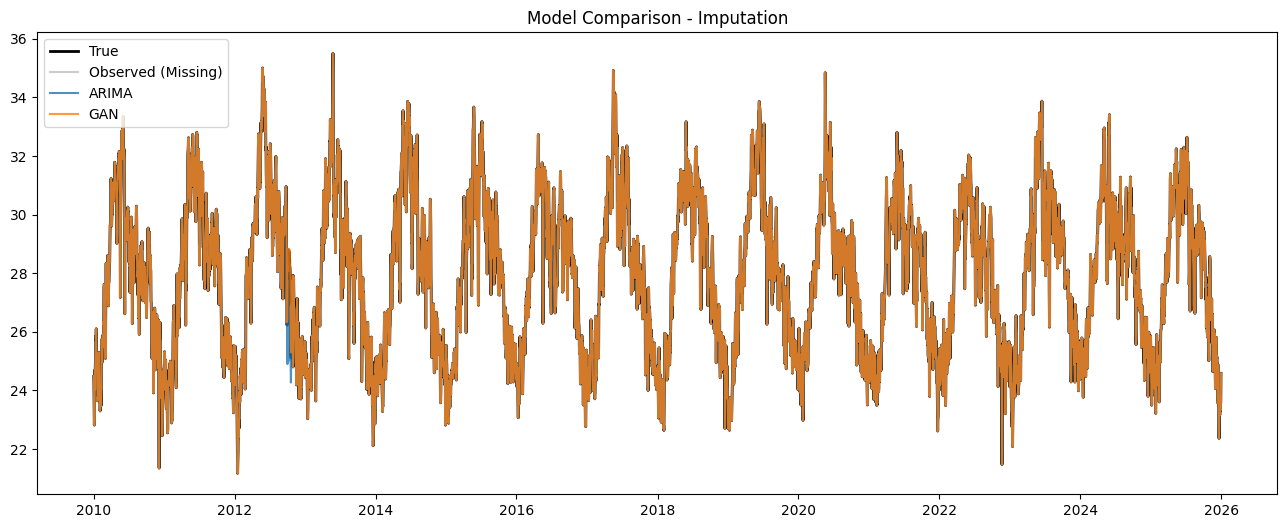

In [113]:
models = {
    "ARIMA": df_arima,
    # "SARIMA": df_sarima,
    # "KNN": df_knn,
    # "LSTM": df_lstm,
    "GAN": df_gan
}

plot_all_models(df_true, df_missing, models, mask)

In [114]:
# =====================================
# Evaluation of All Imputation Models
# =====================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

# -------------------------------------
# Add all models here
# -------------------------------------

models = {
    "ARIMA": df_arima,
    "SARIMA": df_sarima,
    "KNN": df_knn,
    "LSTM": df_lstm,
    "GAN": df_gan
}


# Masked region only

mask_positions = df_missing["temperature_C"].isna()

true_missing = df_true["temperature_C"][mask_positions]

results = []

for name, df_model in models.items():

    pred_missing = df_model["temperature_C"][mask_positions]

    rmse = np.sqrt(mean_squared_error(true_missing, pred_missing))
    mae = mean_absolute_error(true_missing, pred_missing)
    r2 = r2_score(true_missing, pred_missing)

    # Distribution statistics
    mean_diff = abs(true_missing.mean() - pred_missing.mean())
    var_diff = abs(true_missing.var() - pred_missing.var())
    skew_diff = abs(skew(true_missing) - skew(pred_missing))
    kurt_diff = abs(kurtosis(true_missing) - kurtosis(pred_missing))

    # Extreme tail error (top 5%)
    threshold = np.percentile(true_missing, 95)
    extreme_mask = true_missing >= threshold

    extreme_rmse = np.sqrt(mean_squared_error(
        true_missing[extreme_mask],
        pred_missing[extreme_mask]
    ))

    # Autocorrelation (lag-1)
    def lag1_autocorr(x):
        return np.corrcoef(x[:-1], x[1:])[0,1]

    acf_true = lag1_autocorr(true_missing.values)
    acf_pred = lag1_autocorr(pred_missing.values)
    acf_diff = abs(acf_true - acf_pred)

    results.append([
        name, rmse, mae, r2,
        mean_diff, var_diff,
        skew_diff, kurt_diff,
        extreme_rmse, acf_diff
    ])


# Create DataFrame
columns = [
    "Model",
    "RMSE",
    "MAE",
    "R2",
    "Mean_Diff",
    "Variance_Diff",
    "Skewness_Diff",
    "Kurtosis_Diff",
    "Extreme_RMSE",
    "Lag1_ACF_Diff"
]

df_results = pd.DataFrame(results, columns=columns)

# Sort by RMSE
df_results = df_results.sort_values("RMSE")

print("===== Model Evaluation Results =====")
print(df_results)

===== Model Evaluation Results =====
    Model      RMSE       MAE         R2  Mean_Diff  Variance_Diff  \
4     GAN  0.119439  0.088855   0.988704   0.085456       0.104236   
2     KNN  0.776527  0.616049   0.522529   0.081606       0.170922   
1  SARIMA  1.570741  1.406914  -0.953631   1.020642       0.029908   
0   ARIMA  1.663200  1.500684  -1.190393   1.122308       0.046856   
3    LSTM  4.542256  4.320064 -15.337155   4.320064       0.746682   

   Skewness_Diff  Kurtosis_Diff  Extreme_RMSE  Lag1_ACF_Diff  
4       0.025998       0.089574      0.025037       0.016376  
2       0.256426       0.049521      0.754624       0.042170  
1       0.717292       0.726075      1.559165       0.174670  
0       0.786886       1.013296      1.816218       0.175095  
3       2.348052       4.966835      5.921925       0.103698  
